Analise PCD

**Trabalho de Programação Concorrente e Distribuída: Merge Sort sequencial, OpenMP e Pthreads**

**Pergunta de pesquisa:** *Como o tamanho da entrada e o número de threads influenciam o consumo de memória, o desempenho e a eficiência energética de algoritmos de ordenação paralelos?*

**Hipótese:** *Espera-se que o aumento do tamanho da entrada eleve o consumo de memória e o tempo de execução, enquanto o aumento do número de threads reduza o tempo de execução até determinado limite, a partir do qual o overhead de paralelização e a competição pelo acesso à memória reduzam os ganhos de desempenho.*

## 0. Preparação

### 0.1 Configuração

In [1]:
import os, glob, math, textwrap, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

CAMINHO_CSV = "resultados/resultados.csv"

SAIDA = Path("analise")
FIG = SAIDA / "graficos"
TAB = SAIDA / "tabelas"
FIG.mkdir(parents=True, exist_ok=True)
TAB.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------------
# Hardware em que os experimentos rodaram (resultados/ambiente.txt)
# ------------------------------------------------------------------
CPU_NOME = "AMD Ryzen 7 5700X"
NUCLEOS_FISICOS = 8
CPUS_LOGICAS = 16

# Energia estimada (o WSL não mede energia): energia = (P_BASE + P_NUCLEO × núcleos ocupados) × tempo.
P_BASE = 20.0     # W gastos só por estar rodando, independente das threads
P_NUCLEO = 7.0    # W extras por núcleo físico ocupado
ALFA_SMT = 0.3    # thread que divide núcleo (SMT) custa 30% de um núcleo novo


In [2]:
from matplotlib.lines import Line2D

sns.set_theme(context="paper", style="whitegrid", font_scale=1.05)
COR_SEQ, COR_IDEAL, TINTA, TINTA2 = "#52514e", "#9a9892", "#0b0b0b", "#52514e"
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 300,
    "axes.edgecolor": "#b5b3ad", "axes.labelcolor": TINTA,
    "axes.titlesize": 8, "axes.titleweight": "bold",      # título de cada gráfico em negrito
    "figure.titleweight": "bold",                            # título geral (dos gráficos com vários quadros) em negrito
    "axes.labelsize": 6,                                     # rótulos dos eixos ("Threads", "Speedup"...) menores
    "xtick.labelsize": 7.5, "ytick.labelsize": 7.5,          # números dos eixos menores
    "legend.fontsize": 7.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "grid.color": "#e4e3df", "grid.linewidth": 0.6,
    "xtick.color": TINTA2, "ytick.color": TINTA2,
    "legend.frameon": False, "lines.linewidth": 1.6, "lines.markersize": 5,
})

NOME = {"seq": "Sequencial", "omp": "OpenMP", "pthreads": "Pthreads"}
ROTULO = {"seq": "Sequencial", "omp": "OpenMP (tarefas)", "pthreads": "Pthreads (blocos + árvore)"}
PALETA = {ROTULO["omp"]: "#2a78d6", ROTULO["pthreads"]: "#eb6834", ROTULO["seq"]: COR_SEQ}
MARCAS = {ROTULO["omp"]: "o", ROTULO["pthreads"]: "s", ROTULO["seq"]: "^"}
TRACOS = {ROTULO["omp"]: "", ROTULO["pthreads"]: (4, 2), ROTULO["seq"]: (5, 2, 1, 2)}
COR = {"omp": "#2a78d6", "pthreads": "#eb6834"}

# argumentos comuns do seaborn para "uma linha por versão"
POR_VERSAO = dict(hue="Versão", style="Versão", palette=PALETA, markers=MARCAS, dashes=TRACOS)


def fmt_n(n):
    return f"{n / 1e6:g}M"


def com_rotulos(df):
    # Acrescenta as colunas usadas nas legendas: 'Versão' e 'n' (ex.: '40M').
    return df.assign(**{"Versão": df["versao"].map(ROTULO), "n": df["tamanho"].map(fmt_n)})


def salvar(fig, nome):
    # Salva cada gráfico em PNG (300 dpi).
    fig.savefig(FIG / f"{nome}.png", bbox_inches="tight")
    print(f"✔ salvo em {FIG / nome}.png")


def eixo_threads(ax, threads):
    ax.set_xticks(threads)
    ax.set_xticklabels([str(t) for t in threads])
    ax.axvspan(NUCLEOS_FISICOS, max(threads) + 0.5, color="#f2f1ed", zorder=0, lw=0)


def grade_tamanhos(altura=2.35):
    fig, eixos = plt.subplots(2, 3, figsize=(8.6, altura * 2 + 0.6), squeeze=False)
    eixos = eixos.ravel()
    eixos[-1].set_visible(False)
    return fig, eixos[:5]


EXTRAS = {
    "seq": Line2D([], [], color=COR_SEQ, linestyle="-.", lw=1.2, label="Sequencial"),
    "ideal": Line2D([], [], color=COR_IDEAL, linestyle=":", lw=1.2, label="Ideal"),
}


def legenda_figura(fig, extras=()):
    # Uma única legenda embaixo da figura (versões + linhas de referência).
    hs = [Line2D([], [], color=PALETA[ROTULO[v]], marker=MARCAS[ROTULO[v]],
                 linestyle="-" if v == "omp" else "--", label=ROTULO[v]) for v in ("omp", "pthreads")]
    hs += [EXTRAS[e] for e in extras]
    fig.legend(handles=hs, loc="lower center", ncol=len(hs), bbox_to_anchor=(0.5, 0.025))
    fig.tight_layout(rect=(0, 0.09, 1, 1))


NOTA_SMT = (f"Faixa cinza: mais threads que núcleos físicos ({NUCLEOS_FISICOS}); "
            "as threads extras compartilham núcleos via SMT.")

### 0.2 Dados

In [3]:
bruto = pd.read_csv(CAMINHO_CSV)
bruto = bruto.rename(columns={"tempo_segundos": "tempo", "memoria_max_kb": "mem_kb", "cpu_percent": "cpu"})

dados = bruto[bruto["correto"] == "SIM"].copy()       # só execuções com ordenação correta
dados["mem_mib"] = dados["mem_kb"] / 1024
dados = com_rotulos(dados)

TAMANHOS = sorted(int(n) for n in dados["tamanho"].unique())
THREADS = sorted(int(p) for p in dados.loc[dados["versao"] != "seq", "threads"].unique())
VERSOES_PAR = ["omp", "pthreads"]
ORDEM_N = [fmt_n(n) for n in TAMANHOS]
PALETA_N = dict(zip(ORDEM_N, sns.color_palette("Blues", len(TAMANHOS) + 1)[1:]))   # claro -> escuro

print(f"tamanhos: {ORDEM_N} | threads: {THREADS}")

tamanhos: ['1M', '5M', '10M', '20M', '40M'] | threads: [1, 2, 4, 6, 8, 10, 12]


### 0.3 Estatísticas descritivas


In [4]:
def q1(x): return x.quantile(0.25)
def q3(x): return x.quantile(0.75)

resumo = dados.groupby(["versao", "tamanho", "threads"]).agg(
    n_exec=("tempo", "count"),
    tempo_mediana=("tempo", "median"), tempo_media=("tempo", "mean"),
    tempo_dp=("tempo", "std"), tempo_min=("tempo", "min"), tempo_max=("tempo", "max"),
    tempo_q1=("tempo", q1), tempo_q3=("tempo", q3),
    cpu_mediana=("cpu", "median"), mem_mib_mediana=("mem_mib", "median"),
).reset_index()
resumo["tempo_cv_%"] = 100 * resumo["tempo_dp"] / resumo["tempo_media"]
resumo["tempo_iiq"] = resumo["tempo_q3"] - resumo["tempo_q1"]

# Referências: mediana da sequencial (por tamanho) e da paralela com 1 thread
t_seq = resumo[resumo["versao"] == "seq"].set_index("tamanho")["tempo_mediana"]
resumo["tempo_seq"] = resumo["tamanho"].map(t_seq)

resumo.to_csv(TAB / "estatisticas_descritivas.csv", index=False)
resumo[["versao", "tamanho", "threads", "tempo_mediana", "tempo_media", "tempo_dp",
        "tempo_cv_%", "tempo_iiq", "cpu_mediana", "mem_mib_mediana"]].round(4)

,versao,tamanho,threads,tempo_mediana,tempo_media,tempo_dp,tempo_cv_%,tempo_iiq,cpu_mediana,mem_mib_mediana
0,omp,1000000,1,0.0677,0.0678,0.0012,1.7787,0.0019,81.0000,9.7500
1,omp,1000000,2,0.0395,0.0401,0.0014,3.4166,0.0021,135.0000,9.6250
2,omp,1000000,4,0.0306,0.0304,0.0040,13.1600,0.0070,209.0000,9.4375
3,omp,1000000,6,0.0268,0.0267,0.0010,3.8458,0.0013,264.0000,9.3750
4,omp,1000000,8,0.0248,0.0252,0.0018,7.0645,0.0016,326.0000,9.1250
...,...,...,...,...,...,...,...,...,...,...
70,seq,1000000,1,0.0689,0.0707,0.0042,5.9840,0.0034,81.5000,9.2500
71,seq,5000000,1,0.3766,0.3771,0.0030,0.7837,0.0045,85.0000,39.8750
72,seq,10000000,1,0.7944,0.7963,0.0124,1.5552,0.0143,86.0000,78.1250
73,seq,20000000,1,1.6592,1.6645,0.0235,1.4135,0.0218,87.0000,154.3750


## 1. Speedup

**Speedup** S = T_seq / T_p: quantas vezes a versão paralela é mais rápida que a sequencial. O ideal com *p* threads seria S = *p*.

### 1.1 Cálculo

Todas as métricas usam a **mediana** das 10 repetições. Como o speedup é uma **razão de duas medianas**, calculamos também um **intervalo de confiança de 95% por bootstrap**: reamostramos as 10 repetições de cada lado milhares de vezes e vemos como o speedup varia.

In [5]:
RNG = np.random.default_rng(42)
B = 4000

def ic_bootstrap_razao(a, b, B=B):
    # IC 95% de mediana(a) / mediana(b) por bootstrap percentil.
    a, b = np.asarray(a), np.asarray(b)
    ma = np.median(RNG.choice(a, (B, len(a))), axis=1)
    mb = np.median(RNG.choice(b, (B, len(b))), axis=1)
    return np.percentile(ma / mb, [2.5, 97.5])

amostras = {k: g["tempo"].values for k, g in dados.groupby(["versao", "tamanho", "threads"])}

linhas = []
for _, r in resumo[resumo["versao"] != "seq"].iterrows():
    v, n, p = r["versao"], r["tamanho"], r["threads"]
    lo, hi = ic_bootstrap_razao(amostras[("seq", n, 1)], amostras[(v, n, p)])
    linhas.append({"versao": v, "tamanho": n, "threads": p, "S_ic_inf": lo, "S_ic_sup": hi})
ic = pd.DataFrame(linhas)

met = resumo.merge(ic, on=["versao", "tamanho", "threads"], how="left")
t1 = met[met["threads"] == 1].set_index(["versao", "tamanho"])["tempo_mediana"]
met["speedup"] = met["tempo_seq"] / met["tempo_mediana"]
met["speedup_relativo"] = [t1.get((v, n), np.nan) / t for v, n, t in zip(met.versao, met.tamanho, met.tempo_mediana)]
met["eficiencia"] = met["speedup"] / met["threads"]
p_ = met["threads"].astype(float)
met["karp_flatt"] = np.where(p_ > 1, (1 / met["speedup"] - 1 / p_) / (1 - 1 / p_), np.nan)
met["overhead_1thread_%"] = np.where((met["threads"] == 1) & (met["versao"] != "seq"),
                                     100 * (met["tempo_mediana"] / met["tempo_seq"] - 1), np.nan)
par = met[met["versao"] != "seq"].copy()

tab_s = par.pivot_table(index="tamanho", columns=["versao", "threads"], values="speedup")
tab_s.index = [fmt_n(n) for n in tab_s.index]
print("Speedup (T_seq / T_p), mediana:")
tab_s.round(2)

Speedup (T_seq / T_p), mediana:


versao     omp                                           pthreads                                          
threads     1      2      4      6      8      10     12       1      2      4      6      8      10     12
1M      1.0200 1.7400 2.2500 2.5700 2.7800 2.9400 3.0300   1.0200 1.8700 2.9500 3.6700 4.3300 4.5600 4.8600
5M      1.0100 1.7500 2.6200 2.5600 2.9500 3.1700 3.3000   1.0000 1.8800 3.0700 3.8400 4.4600 4.7600 4.8400
10M     1.0100 1.7600 2.2600 2.6600 3.1000 3.2900 3.4400   1.0100 1.8800 3.1600 3.9000 4.6200 4.7300 4.8400
20M     1.0200 1.7600 2.6200 2.7200 3.0100 3.3100 3.4700   1.0300 1.9000 3.2400 4.0100 4.6600 4.8400 5.2100
40M     1.0100 1.7900 2.2800 2.7400 3.0100 3.4100 3.5800   1.0300 1.9300 3.2700 4.0700 4.6800 4.8300 5.1200

### 1.2 Speedup × número de threads

✔ salvo em analise\graficos\1_speedup.png


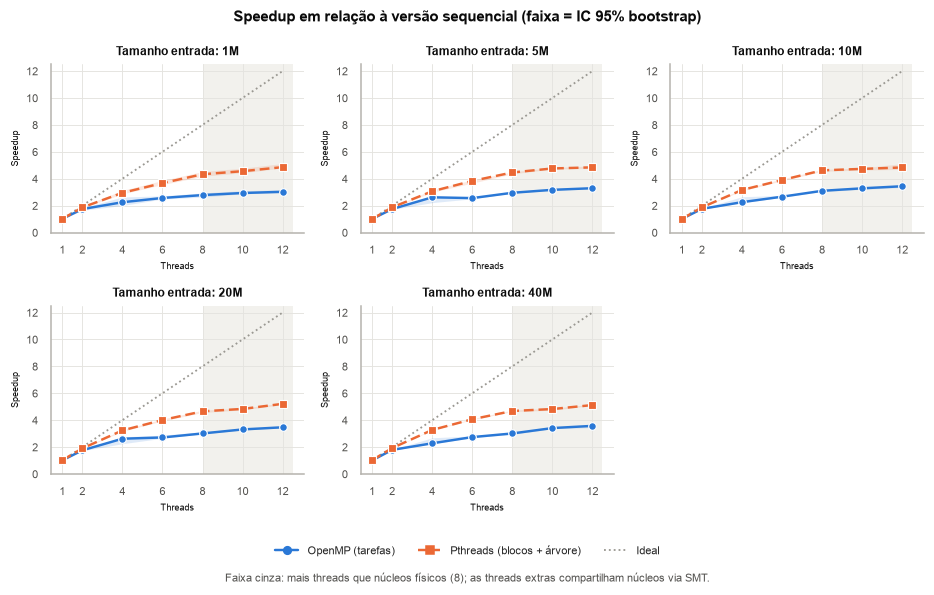

In [6]:
par_r = com_rotulos(par)
fig, eixos = grade_tamanhos()
for ax, n in zip(eixos, TAMANHOS):
    ax.plot(THREADS, THREADS, color=COR_IDEAL, linestyle=":", lw=1.2)
    sub = par_r[par_r["tamanho"] == n]
    sns.lineplot(data=sub, x="threads", y="speedup", **POR_VERSAO, errorbar=None, legend=False, ax=ax)
    for v in VERSOES_PAR:
        s = sub[sub["versao"] == v].sort_values("threads")
        ax.fill_between(s["threads"], s["S_ic_inf"], s["S_ic_sup"], color=COR[v], alpha=0.15, lw=0)
    eixo_threads(ax, THREADS)
    ax.set_ylim(0, max(THREADS) + 0.5)
    ax.set_title(f"Tamanho entrada: {fmt_n(n)}", color=TINTA)
    ax.set_xlabel("Threads"); ax.set_ylabel("Speedup")
fig.suptitle("Speedup em relação à versão sequencial (faixa = IC 95% bootstrap)", color=TINTA, fontsize=10)
legenda_figura(fig, extras=["ideal"])
fig.text(0.5, 0.0, NOTA_SMT, ha="center", fontsize=7.5, color=TINTA2)
salvar(fig, "1_speedup")
plt.show()

### 1.3 Por que o speedup para de crescer: Lei de Amdahl

No Merge Sort, a parte serial é o **merge final**: juntar as duas metades ordenadas do vetor só pode ser feito por uma thread, enquanto as outras esperam. Como não sabemos o valor de *f*, escolhemos o que faz a curva de Amdahl passar mais perto dos speedups medidos (usando até 8 threads, antes do SMT).

In [7]:
from scipy.optimize import curve_fit

def amdahl(p, f):
    return 1.0 / (f + (1.0 - f) / p)

linhas = []
for (v, n), s in par.groupby(["versao", "tamanho"]):
    s8 = s[s["threads"] <= NUCLEOS_FISICOS]
    (f,), _ = curve_fit(amdahl, s8["threads"].values, s8["speedup"].values, p0=[0.1], bounds=(0, 1))
    s12 = s[s["threads"] == max(THREADS)]["speedup"].iloc[0]
    linhas.append({"versao": v, "tamanho": n, "f_serial_amdahl": f, "S_max_teorico (1/f)": 1 / f,
                   f"S_previsto_{max(THREADS)}": amdahl(max(THREADS), f), f"S_medido_{max(THREADS)}": s12})
amd = pd.DataFrame(linhas)
amd.to_csv(TAB / "amdahl.csv", index=False)
amd.assign(tamanho=amd["tamanho"].map(fmt_n)).round(3)

,versao,tamanho,f_serial_amdahl,S_max_teorico (1/f),S_previsto_12,S_medido_12
0,omp,1M,0.2640,3.7910,3.0760,3.0300
1,omp,5M,0.2390,4.1800,3.3040,3.2960
2,omp,10M,0.2360,4.2300,3.3330,3.4410
3,omp,20M,0.2270,4.3990,3.4280,3.4730
4,omp,40M,0.2370,4.2240,3.3300,3.5780
5,pthreads,1M,0.1220,8.1910,5.1220,4.8610
6,pthreads,5M,0.1120,8.9540,5.3850,4.8450
7,pthreads,10M,0.1040,9.6470,5.6070,4.8360
8,pthreads,20M,0.0990,10.0880,5.7410,5.2150
9,pthreads,40M,0.0970,10.3470,5.8170,5.1240


✔ salvo em analise\graficos\1_amdahl.png


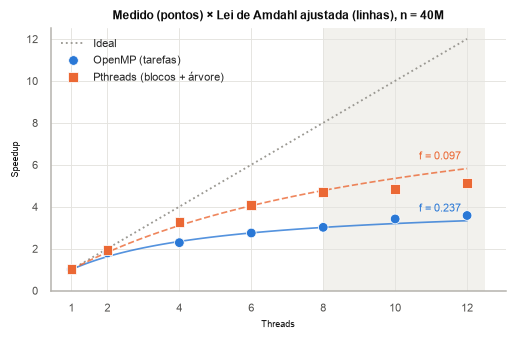

In [8]:
fig, ax = plt.subplots(figsize=(4.8, 3.2))
n = max(TAMANHOS)
sub = par_r[par_r["tamanho"] == n]

# speedup medido (pontos) x curva de Amdahl ajustada (linhas)
pp = np.linspace(1, max(THREADS), 100)
ax.plot(pp, pp, color=COR_IDEAL, linestyle=":", lw=1.2, label="Ideal")
sns.scatterplot(data=sub, x="threads", y="speedup", hue="Versão", style="Versão", palette=PALETA,
                markers=MARCAS, s=40, ax=ax, zorder=3)
for v in VERSOES_PAR:
    f = amd[(amd["versao"] == v) & (amd["tamanho"] == n)]["f_serial_amdahl"].iloc[0]
    ax.plot(pp, amdahl(pp, f), color=COR[v], lw=1.1, linestyle="-" if v == "omp" else "--", alpha=0.8)
    ax.annotate(f"f = {f:.3f}", (pp[-1], amdahl(pp[-1], f)), textcoords="offset points",
                xytext=(-4, 6), ha="right", fontsize=7.5, color=COR[v])
eixo_threads(ax, THREADS)
ax.set_ylim(0, max(THREADS) + 0.5)
ax.set_xlabel("Threads"); ax.set_ylabel("Speedup")
ax.set_title(f"Medido (pontos) × Lei de Amdahl ajustada (linhas), n = {fmt_n(n)}", color=TINTA)
ax.legend(title=None, fontsize=7.5, loc="upper left")
fig.tight_layout()
salvar(fig, "1_amdahl")
plt.show()

### 1.4 OpenMP × Pthreads

As duas versões usam exatamente o mesmo `merge` e o mesmo `merge_sort` sequencial: a diferença está **só na forma de dividir o trabalho**. A razão T_OpenMP / T_Pthreads > 1 indica que o Pthreads foi mais rápido.

✔ salvo em analise\graficos\1_omp_vs_pthreads.png


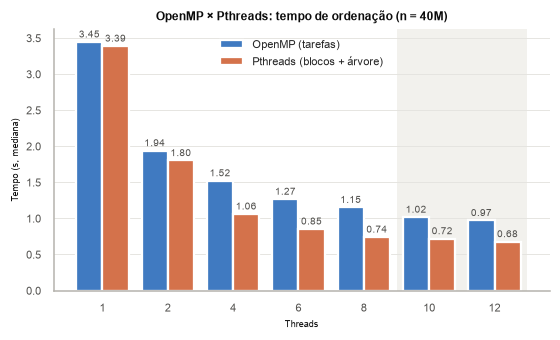

Quanto o OpenMP foi mais lento que o Pthreads (%):


threads,1,2,4,6,8,10,12
1M,0%,7%,31%,43%,56%,55%,60%
5M,-1%,8%,17%,50%,51%,50%,47%
10M,0%,6%,40%,47%,49%,44%,41%
20M,1%,8%,23%,48%,55%,46%,50%
40M,2%,8%,43%,48%,55%,41%,43%


In [9]:
# Tempo das duas versões lado a lado, na maior entrada
n = max(TAMANHOS)
sub = par_r[par_r["tamanho"] == n]

fig, ax = plt.subplots(figsize=(5.2, 3.2))
sns.barplot(data=sub, x="threads", y="tempo_mediana", hue="Versão", palette=PALETA,
            edgecolor="white", linewidth=1.5, ax=ax)
ax.axvspan(THREADS.index(NUCLEOS_FISICOS) + 0.5, len(THREADS) - 0.5, color="#f2f1ed", zorder=0, lw=0)
for barras in ax.containers:
    ax.bar_label(barras, fmt="%.2f", fontsize=6.5, padding=1.5, color=TINTA2)
ax.set_xlabel("Threads"); ax.set_ylabel("Tempo (s, mediana)")
ax.set_title(f"OpenMP × Pthreads: tempo de ordenação (n = {fmt_n(n)})", color=TINTA)
ax.legend(title=None, fontsize=7.5)
fig.tight_layout()
salvar(fig, "1_omp_vs_pthreads")
plt.show()

# Quanto o OpenMP foi mais lento que o Pthreads, em %, para todos os tamanhos
comp = par.pivot_table(index=["tamanho", "threads"], columns="versao", values="tempo_mediana").reset_index()
comp["omp_mais_lento_%"] = 100 * (comp["omp"] / comp["pthreads"] - 1)
t = comp.pivot(index="tamanho", columns="threads", values="omp_mais_lento_%")
t.index = [fmt_n(n) for n in t.index]
print("Quanto o OpenMP foi mais lento que o Pthreads (%):")
t.round(0).astype(int).astype(str) + "%"

## 2. Eficiência paralela

**Eficiência** E = S / *p*: quanto de cada thread está sendo aproveitado. 100% = aproveitamento perfeito; 50% = cada thread "rende" metade do que poderia.

### 2.1 Eficiência × número de threads

✔ salvo em analise\graficos\2_eficiencia.png


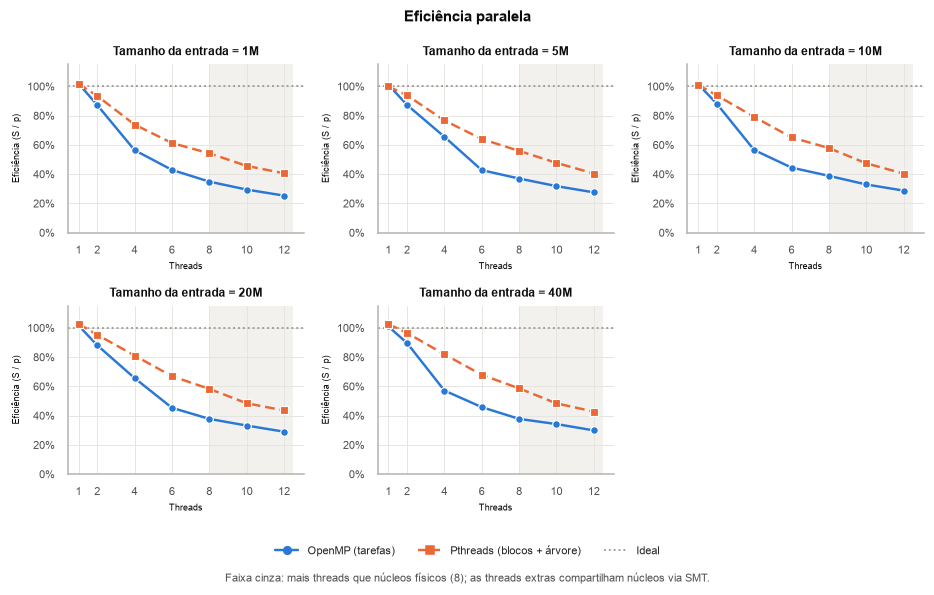

In [10]:
fig, eixos = grade_tamanhos()
for ax, n in zip(eixos, TAMANHOS):
    ax.axhline(1, color=COR_IDEAL, linestyle=":", lw=1.2)
    sns.lineplot(data=par_r[par_r["tamanho"] == n], x="threads", y="eficiencia", **POR_VERSAO,
                 errorbar=None, legend=False, ax=ax)
    eixo_threads(ax, THREADS)
    ax.set_ylim(0, 1.15)
    ax.yaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(1.0))
    ax.set_title(f"Tamanho da entrada = {fmt_n(n)}", color=TINTA)
    ax.set_xlabel("Threads"); ax.set_ylabel("Eficiência (S / p)")
fig.suptitle("Eficiência paralela", color=TINTA, fontsize=10)
legenda_figura(fig, extras=["ideal"])
fig.text(0.5, 0.0, NOTA_SMT, ha="center", fontsize=7.5, color=TINTA2)
salvar(fig, "2_eficiencia")
plt.show()

In [11]:
tab_e = par.pivot_table(index="tamanho", columns=["versao", "threads"], values="eficiencia")
tab_e.index = [fmt_n(n) for n in tab_e.index]
print("Eficiência paralela (S / p):")
(tab_e * 100).round(0).astype(int).astype(str) + "%"

Eficiência paralela (S / p):


versao    omp                               pthreads                              
threads    1    2    4    6    8    10   12       1    2    4    6    8    10   12
1M       102%  87%  56%  43%  35%  29%  25%     102%  93%  74%  61%  54%  46%  41%
5M       101%  87%  65%  43%  37%  32%  27%     100%  94%  77%  64%  56%  48%  40%
10M      101%  88%  56%  44%  39%  33%  29%     101%  94%  79%  65%  58%  47%  40%
20M      102%  88%  66%  45%  38%  33%  29%     103%  95%  81%  67%  58%  48%  43%
40M      101%  90%  57%  46%  38%  34%  30%     103%  96%  82%  68%  59%  48%  43%

**Leitura:** a eficiência cai à medida que se adicionam threads: nenhuma configuração acima de 2 threads mantém 100%. Com 12 threads (n = 40M) o Pthreads aproveita ~43% de cada thread e o OpenMP ~30%. O Pthreads é mais eficiente em todos os casos a partir de 2 threads.

### 2.2 Overhead com 1 thread

Compara a versão paralela com **1 thread** com a sequencial: mede o custo de usar o OpenMP/Pthreads sem nenhum ganho de paralelismo.

In [12]:
print("Overhead da versão paralela com 1 thread em relação à sequencial (positivo = mais lenta):")
oh = par[par["threads"] == 1].pivot(index="tamanho", columns="versao", values="overhead_1thread_%")
oh.index = [fmt_n(n) for n in oh.index]
oh.round(2)

Overhead da versão paralela com 1 thread em relação à sequencial (positivo = mais lenta):


versao,omp,pthreads
1M,-1.8400,-1.6300
5M,-1.0900,0.0600
10M,-1.4400,-0.9800
20M,-1.5500,-2.6100
40M,-0.8700,-2.5100


### 2.3 Onde está o limite?

A hipótese fala em um **limite a partir do qual os ganhos diminuem**. Para localizá-lo, olhamos o **ganho marginal**: quanto o tempo cai a cada passo de threads (1→2, 2→4, …, 10→12). Também testamos se o passo de **8 → 12 threads** ainda traz uma redução **estatisticamente significativa** (teste de Mann–Whitney, não paramétrico, unilateral, α = 0,05).

✔ salvo em analise\graficos\2_ganho_marginal.png


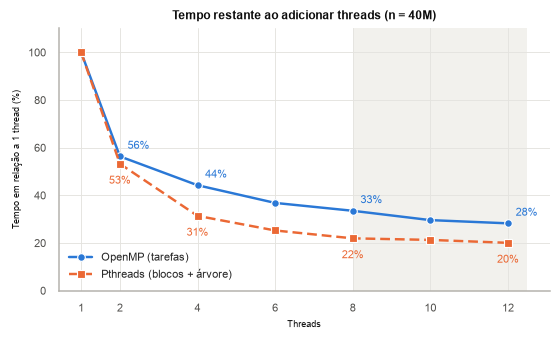

12 threads são mais rápidas que 8? (Mann–Whitney unilateral)


,versao,tamanho,t_8,t_12,reducao_%,p_valor,"significativo (α=0,05)"
0,omp,1M,0.0248,0.0227,8.0876,0.0086,sim
1,omp,5M,0.1274,0.1143,10.3355,0.0001,sim
2,omp,10M,0.2562,0.2309,9.8793,0.0001,sim
3,omp,20M,0.5505,0.4778,13.2083,0.0001,sim
4,omp,40M,1.1534,0.9718,15.7476,0.0001,sim
5,pthreads,1M,0.0159,0.0142,10.8693,0.0001,sim
6,pthreads,5M,0.0843,0.0777,7.8414,0.0001,sim
7,pthreads,10M,0.1718,0.1643,4.4110,0.0018,sim
8,pthreads,20M,0.3562,0.3182,10.6694,0.0001,sim
9,pthreads,40M,0.7423,0.6785,8.5963,0.0001,sim


In [13]:
# Tempo restante em relação à própria versão com 1 thread, na maior entrada
n = max(TAMANHOS)
s = par_r[par_r["tamanho"] == n].copy()
t1 = s[s["threads"] == 1].set_index("versao")["tempo_mediana"]
s["tempo_rel_%"] = 100 * s["tempo_mediana"] / s["versao"].map(t1)

fig, ax = plt.subplots(figsize=(5.2, 3.2))
ax.axvspan(NUCLEOS_FISICOS, max(THREADS) + 0.5, color="#f2f1ed", zorder=0, lw=0)
sns.lineplot(data=s, x="threads", y="tempo_rel_%", **POR_VERSAO, errorbar=None, ax=ax)
for _, r in s[s["threads"].isin([2, 4, 8, 12])].iterrows():
    ax.annotate(f"{r['tempo_rel_%']:.0f}%", (r["threads"], r["tempo_rel_%"]), textcoords="offset points",
                xytext=(5, 5) if r["versao"] == "omp" else (0, -13), ha="left" if r["versao"] == "omp" else "center", fontsize=7, color=COR[r["versao"]])
ax.set_xticks(THREADS); ax.set_ylim(0, 110)
ax.set_xlabel("Threads"); ax.set_ylabel("Tempo em relação a 1 thread (%)")
ax.set_title(f"Tempo restante ao adicionar threads (n = {fmt_n(n)})", color=TINTA)
ax.legend(title=None, fontsize=7.5)
fig.tight_layout()
salvar(fig, "2_ganho_marginal")
plt.show()

# Teste estatístico: 12 threads é mais rápido que 8?
linhas = []
for v in VERSOES_PAR:
    for n in TAMANHOS:
        a, b = amostras[(v, n, NUCLEOS_FISICOS)], amostras[(v, n, max(THREADS))]
        u, pval = stats.mannwhitneyu(b, a, alternative="less")
        linhas.append({"versao": v, "tamanho": fmt_n(n),
                       f"t_{NUCLEOS_FISICOS}": np.median(a), f"t_{max(THREADS)}": np.median(b),
                       "reducao_%": 100 * (1 - np.median(b) / np.median(a)), "p_valor": pval,
                       "significativo (α=0,05)": "sim" if pval < 0.05 else "não"})
teste = pd.DataFrame(linhas)
teste.to_csv(TAB / "teste_8_vs_12_threads.csv", index=False)
print(f"{max(THREADS)} threads são mais rápidas que {NUCLEOS_FISICOS}? (Mann–Whitney unilateral)")
teste.round(4)

**Leitura:**
* O ganho por thread adicionada é grande no começo (1→2 threads) e **cai de forma contínua**: é a "lei dos retornos decrescentes" da paralelização.
* A partir de **8 threads (= número de núcleos físicos)** o ganho por thread extra fica pequeno (≈ 1–5% por thread). Ir de 8 para 12 threads ainda reduz o tempo de forma **estatisticamente significativa em todos os casos**, mas pouco: 4–11% no Pthreads e 8–16% no OpenMP, com 50% mais threads.
* No OpenMP aparece uma irregularidade entre 4 e 6 threads (em 5M o passo 4→6 chega a piorar), ligada à instabilidade das execuções com 4 threads: os tempos se dividem em dois grupos (faixa interquartil larga no gráfico 4.2), provavelmente porque o sistema nem sempre coloca as threads em núcleos diferentes.
* Em nenhum caso o tempo **aumentou** ao adicionar threads (até 12). Como 12 < 16 CPUs lógicas, nunca houve mais threads do que o hardware oferece; com mais threads que CPUs lógicas seria esperado que o tempo voltasse a subir.

### 2.4 Utilização de CPU (eficiência no uso do processador)

`cpu_percent` é o uso médio de CPU do processo inteiro, medido pelo `/usr/bin/time`: 100% = um núcleo ocupado o tempo todo. **Atenção:** ele inclui a leitura do arquivo e a validação, que são sequenciais e fora do cronômetro. Por isso subestima o uso durante a ordenação (a sequencial aparece com ~85%, e não 100%, por causa da espera pela leitura do arquivo).

Dividindo por 100 temos os **"núcleos equivalentes ocupados"**, que podem ser comparados com o número de threads pedido.

✔ salvo em analise\graficos\2_utilizacao_cpu.png


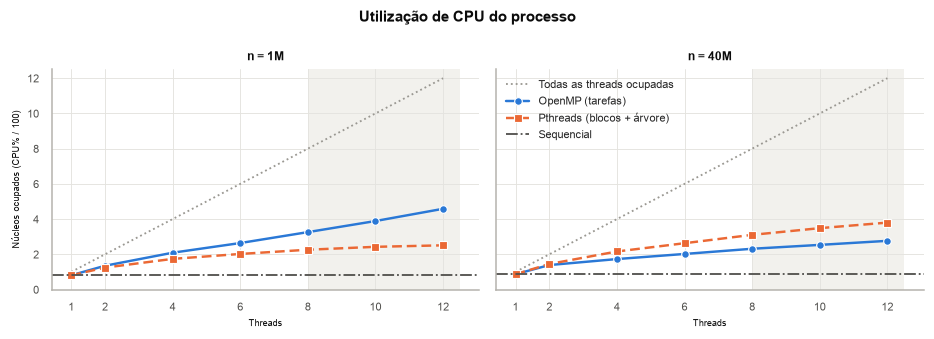

CPU% mediano do processo:


versao      omp                                                       pthreads                                                      
threads      1        2        4        6        8        10       12       1        2        4        6        8        10       12
1M      81.0000 135.0000 209.0000 264.0000 326.0000 389.0000 458.0000  81.0000 124.0000 174.0000 202.0000 226.0000 242.0000 251.0000
5M      85.0000 137.0000 198.0000 221.0000 260.0000 296.0000 334.0000  86.0000 138.0000 199.0000 234.0000 270.0000 290.0000 320.0000
10M     86.0000 136.0000 172.0000 204.0000 242.0000 266.0000 294.0000  86.0000 140.0000 204.0000 246.0000 279.0000 311.0000 334.0000
20M     87.0000 138.0000 186.0000 205.0000 230.0000 254.0000 278.0000  87.0000 144.0000 211.0000 254.0000 294.0000 329.0000 358.0000
40M     87.0000 139.0000 173.0000 202.0000 232.0000 254.0000 276.0000  87.0000 145.0000 216.0000 263.0000 310.0000 348.0000 380.0000

In [14]:
rc = com_rotulos(resumo)
rc["nucleos_ocupados"] = rc["cpu_mediana"] / 100
fig, eixos = plt.subplots(1, 2, figsize=(8.6, 3.1), sharey=True)
for ax, n in zip(eixos, [min(TAMANHOS), max(TAMANHOS)]):
    ax.plot(THREADS, THREADS, color=COR_IDEAL, linestyle=":", lw=1.2, label="Todas as threads ocupadas")
    sns.lineplot(data=rc[(rc.versao != "seq") & (rc.tamanho == n)], x="threads", y="nucleos_ocupados",
                 **POR_VERSAO, errorbar=None, ax=ax)
    ax.axhline(rc[(rc.versao == "seq") & (rc.tamanho == n)]["nucleos_ocupados"].iloc[0],
               color=COR_SEQ, linestyle="-.", lw=1.2, label="Sequencial")
    eixo_threads(ax, THREADS)
    ax.set_ylim(0, max(THREADS) + 0.5)
    ax.set_xlabel("Threads"); ax.set_ylabel("Núcleos ocupados (CPU% / 100)")
    ax.set_title(f"n = {fmt_n(n)}", color=TINTA)
    ax.legend().remove()
h, l = eixos[1].get_legend_handles_labels()
eixos[1].legend(h, l, fontsize=7.5, title=None)
fig.suptitle("Utilização de CPU do processo", color=TINTA, fontsize=10)
fig.tight_layout()
salvar(fig, "2_utilizacao_cpu")
plt.show()

u = resumo[resumo.versao != "seq"].pivot_table(index="tamanho", columns=["versao", "threads"], values="cpu_mediana")
u.index = [fmt_n(n) for n in u.index]
print("CPU% mediano do processo:")
u.round(0)

## 3. Consumo e eficiência energética



### 3.2 Energia relativa ao sequencial

✔ salvo em analise\graficos\3_energia_relativa.png


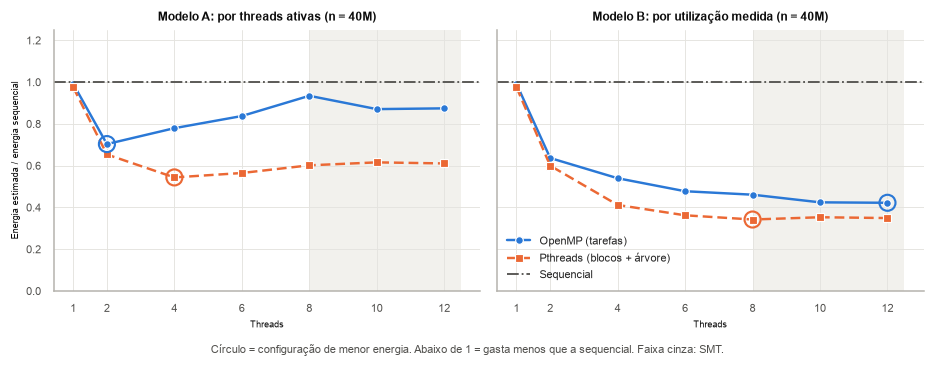

Energia relativa ao sequencial — Modelo A:


versao     omp                                           pthreads                                          
threads     1      2      4      6      8      10     12       1      2      4      6      8      10     12
1M      0.9800 0.7200 0.7900 0.8900 1.0100 1.0100 1.0300   0.9800 0.6700 0.6000 0.6300 0.6500 0.6500 0.6400
5M      0.9900 0.7200 0.6800 0.9000 0.9500 0.9400 0.9500   1.0000 0.6700 0.5800 0.6000 0.6300 0.6200 0.6500
10M     0.9900 0.7100 0.7900 0.8600 0.9100 0.9000 0.9100   0.9900 0.6700 0.5600 0.5900 0.6100 0.6300 0.6500
20M     0.9800 0.7200 0.6800 0.8500 0.9300 0.9000 0.9000   0.9700 0.6600 0.5500 0.5700 0.6000 0.6100 0.6000
40M     0.9900 0.7000 0.7800 0.8400 0.9300 0.8700 0.8700   0.9700 0.6500 0.5400 0.5600 0.6000 0.6200 0.6100

In [15]:
def nucleos_ativos(p):
    p = np.asarray(p, dtype=float)
    return np.minimum(p, NUCLEOS_FISICOS) + ALFA_SMT * np.maximum(0, p - NUCLEOS_FISICOS)


def energia(df, modelo, p_base=P_BASE, p_nucleo=P_NUCLEO):
    if modelo == "A":
        pot = p_base + p_nucleo * nucleos_ativos(df["threads"])
    else:
        pot = p_base + p_nucleo * df["cpu_mediana"] / 100
    return pot * df["tempo_mediana"], pot


en = resumo.copy()
for m in ["A", "B"]:
    en[f"E_{m}"], en[f"P_{m}"] = energia(en, m)
    e_seq = en[en.versao == "seq"].set_index("tamanho")[f"E_{m}"]
    en[f"E_{m}_rel"] = en[f"E_{m}"] / en["tamanho"].map(e_seq)
    en[f"EDP_{m}_rel"] = (en[f"E_{m}"] * en["tempo_mediana"]) / (en["tamanho"].map(e_seq) * en["tempo_seq"])
en.to_csv(TAB / "energia_estimada.csv", index=False)

enp = com_rotulos(en[en.versao != "seq"])
fig, eixos = plt.subplots(1, 2, figsize=(8.6, 3.2), sharey=True)
n = max(TAMANHOS)
for ax, m, titulo in zip(eixos, ["A", "B"], ["Modelo A: por threads ativas", "Modelo B: por utilização medida"]):
    sub = enp[enp.tamanho == n]
    sns.lineplot(data=sub, x="threads", y=f"E_{m}_rel", **POR_VERSAO, errorbar=None, ax=ax)
    for v in VERSOES_PAR:
        s = sub[sub.versao == v]
        i = s[f"E_{m}_rel"].idxmin()
        ax.scatter([s.loc[i, "threads"]], [s.loc[i, f"E_{m}_rel"]], s=110, facecolors="none",
                   edgecolors=COR[v], linewidths=1.4, zorder=4)
    ax.axhline(1, color=COR_SEQ, linestyle="-.", lw=1.2, label="Sequencial")
    ax.set_ylabel("Energia estimada / energia sequencial")
    ax.legend().remove()
    eixo_threads(ax, THREADS)
    ax.set_ylim(0, 1.25)
    ax.set_xlabel("Threads"); ax.set_title(f"{titulo} (n = {fmt_n(n)})", color=TINTA)
h, l = eixos[1].get_legend_handles_labels()
eixos[1].legend(h, l, fontsize=7.5, title=None)
fig.text(0.5, -0.02, "Círculo = configuração de menor energia. Abaixo de 1 = gasta menos que a sequencial. Faixa cinza: SMT.",
         ha="center", fontsize=7.5, color=TINTA2)
fig.tight_layout()
salvar(fig, "3_energia_relativa")
plt.show()

t = enp.pivot_table(index="tamanho", columns=["versao", "threads"], values="E_A_rel")
t.index = [fmt_n(n) for n in t.index]
print("Energia relativa ao sequencial — Modelo A:")
t.round(2)

### 3.3 Tempo × energia: o mais rápido é o mais econômico?

✔ salvo em analise\graficos\3_tempo_vs_energia.png


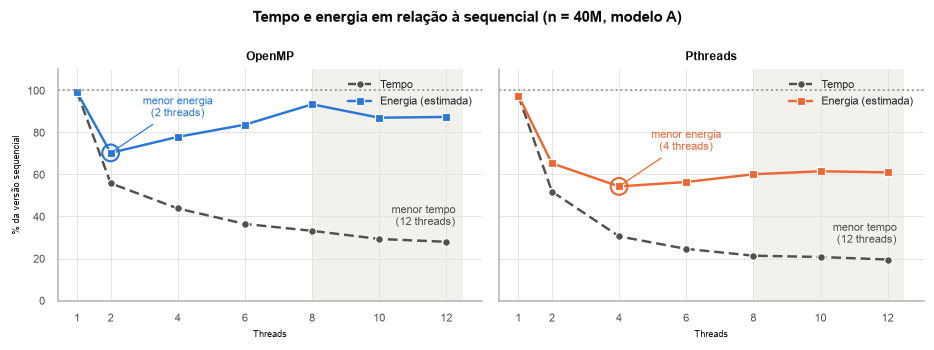

In [16]:
# O mais rápido é o mais econômico? Tempo e energia (modelo A) em % da sequencial, n = 40M
n = max(TAMANHOS)
d = en[(en["versao"] != "seq") & (en["tamanho"] == n)].copy()
d["Tempo"] = 100 * d["tempo_mediana"] / d["tempo_seq"]
d["Energia (estimada)"] = 100 * d["E_A_rel"]
longo = d.melt(id_vars=["versao", "threads"], value_vars=["Tempo", "Energia (estimada)"],
               var_name="Medida", value_name="pct")

fig, eixos = plt.subplots(1, 2, figsize=(8.6, 3.2), sharey=True)
for ax, v in zip(eixos, VERSOES_PAR):
    s = longo[longo["versao"] == v]
    ax.axvspan(NUCLEOS_FISICOS, max(THREADS) + 0.5, color="#f2f1ed", zorder=0, lw=0)
    sns.lineplot(data=s, x="threads", y="pct", hue="Medida", style="Medida",
                 palette={"Tempo": COR_SEQ, "Energia (estimada)": COR[v]},
                 markers={"Tempo": "o", "Energia (estimada)": "s"}, dashes={"Tempo": (4, 2), "Energia (estimada)": ""},
                 errorbar=None, ax=ax)
    # marca o ponto de menor energia e o de menor tempo
    e = s[s["Medida"] == "Energia (estimada)"]; t = s[s["Medida"] == "Tempo"]
    pe = e.loc[e["pct"].idxmin()]; pt = t.loc[t["pct"].idxmin()]
    ax.scatter([pe["threads"]], [pe["pct"]], s=120, facecolors="none", edgecolors=COR[v], linewidths=1.4, zorder=4)
    ax.annotate(f"menor energia\n({int(pe['threads'])} threads)", (pe["threads"], pe["pct"]),
                xytext=(pe["threads"] + 2, pe["pct"] + 16), ha="center", va="bottom", fontsize=7, color=COR[v],
                arrowprops=dict(arrowstyle="-", color=COR[v], lw=0.8))
    ax.annotate(f"menor tempo\n({int(pt['threads'])} threads)", (pt["threads"], pt["pct"]), textcoords="offset points",
                xytext=(6, 9), ha="right", va="bottom", fontsize=7, color=COR_SEQ)
    ax.axhline(100, color=COR_IDEAL, linestyle=":", lw=1.2)
    ax.set_xticks(THREADS); ax.set_ylim(0, 110)
    ax.set_xlabel("Threads"); ax.set_ylabel("% da versão sequencial")
    ax.set_title(NOME[v], color=TINTA)
    ax.legend(title=None, fontsize=7.5, loc="upper right")
fig.suptitle(f"Tempo e energia em relação à sequencial (n = {fmt_n(n)}, modelo A)", color=TINTA, fontsize=10)
fig.tight_layout()
salvar(fig, "3_tempo_vs_energia")
plt.show()

### 3.4 Melhor configuração: menor tempo × menor energia × menor EDP

In [17]:
linhas = []
for (v, n), s in enp.groupby(["versao", "tamanho"]):
    linhas.append({
        "versao": v, "tamanho": fmt_n(n),
        "p_menor_tempo": int(s.loc[s["tempo_mediana"].idxmin(), "threads"]),
        "p_menor_energia_A": int(s.loc[s["E_A"].idxmin(), "threads"]),
        "p_menor_energia_B": int(s.loc[s["E_B"].idxmin(), "threads"]),
        "p_menor_EDP_A": int(s.loc[s["EDP_A_rel"].idxmin(), "threads"]),
        "E_A_rel_no_mais_rapido": s.loc[s["tempo_mediana"].idxmin(), "E_A_rel"],
        "E_A_rel_minima": s["E_A_rel"].min(),
    })
melhores = pd.DataFrame(linhas)
melhores["mais_rapido_=_mais_economico (A)"] = np.where(melhores["p_menor_tempo"] == melhores["p_menor_energia_A"], "sim", "NÃO")
melhores.to_csv(TAB / "melhores_configuracoes.csv", index=False)
melhores.round(3)

,versao,tamanho,p_menor_tempo,p_menor_energia_A,p_menor_energia_B,p_menor_EDP_A,E_A_rel_no_mais_rapido,E_A_rel_minima,mais_rapido_=_mais_economico (A)
0,omp,1M,12,2,6,12,1.0320,0.7220,NÃO
1,omp,5M,12,4,10,4,0.9490,0.6790,NÃO
2,omp,10M,12,2,10,12,0.9080,0.7150,NÃO
3,omp,20M,12,4,12,4,0.9000,0.6780,NÃO
4,omp,40M,12,2,12,12,0.8740,0.7030,NÃO
5,pthreads,1M,12,4,12,12,0.6430,0.6020,NÃO
6,pthreads,5M,12,4,10,10,0.6450,0.5800,NÃO
7,pthreads,10M,12,4,8,8,0.6460,0.5620,NÃO
8,pthreads,20M,12,4,12,12,0.5990,0.5490,NÃO
9,pthreads,40M,12,4,8,12,0.6100,0.5430,NÃO


### 3.5 Análise de sensibilidade

Os parâmetros do modelo são estimativas, então variamos **P_base** (a potência "de fundo") para ver se a resposta muda. A tabela mostra, para n = 40M, **qual número de threads minimiza a energia** em cada cenário.

In [18]:
bases = [5, 10, 20, 30, 40]
linhas = []
for pb in bases:
    for m in ["A", "B"]:
        e_all = en.copy()
        e_all["E"], _ = energia(e_all, m, p_base=pb)
        n = max(TAMANHOS)
        e_seq = e_all[(e_all.versao == "seq") & (e_all.tamanho == n)]["E"].iloc[0]
        for v in VERSOES_PAR:
            s = e_all[(e_all.versao == v) & (e_all.tamanho == n)]
            i = s["E"].idxmin()
            linhas.append({"P_base (W)": pb, "modelo": m, "versao": v,
                           "p_menor_energia": int(s.loc[i, "threads"]),
                           "E_min / E_seq": s.loc[i, "E"] / e_seq,
                           f"E({max(THREADS)} thr) / E_seq": s[s.threads == max(THREADS)]["E"].iloc[0] / e_seq})
sens = pd.DataFrame(linhas)
sens.to_csv(TAB / "sensibilidade_energia.csv", index=False)
sens.pivot_table(index="P_base (W)", columns=["modelo", "versao"], values=["p_menor_energia", "E_min / E_seq"]).round(2)

E_min / E_seq                          p_menor_energia                          
modelo                 A               B                        A                B         
versao               omp pthreads    omp pthreads             omp pthreads     omp pthreads
P_base (W)                                                                                 
5                 0.8800   0.8200 0.6000   0.5100          2.0000   2.0000 10.0000   8.0000
10                0.7900   0.6800 0.5100   0.4200          2.0000   4.0000 10.0000   8.0000
20                0.7000   0.5400 0.4200   0.3400          2.0000   4.0000 12.0000   8.0000
30                0.6600   0.4800 0.3800   0.3100          2.0000   6.0000 12.0000  12.0000
40                0.6200   0.4300 0.3600   0.2800         12.0000   6.0000 12.0000  12.0000

## 4. Gráficos comparativos: tamanho da entrada, número de threads, tempo, memória e energia

Visão conjunta de como **tamanho da entrada** e **número de threads** afetam cada recurso medido.

### 4.1 Tempo × tamanho da entrada

O Merge Sort tem complexidade **O(n log n)**: dobrar a entrada deveria multiplicar o tempo por um pouco mais de 2. Para verificar, dividimos o tempo por n·log₂n. Se o valor resultante (nanossegundos por "unidade de trabalho") ficar aproximadamente constante, o tempo cresce como previsto pela teoria.

C:\Users\aline\AppData\Local\Temp\ipykernel_24160\1775329762.py:20: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\aline\AppData\Local\Temp\ipykernel_24160\1312958126.py:41: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.savefig(FIG / f"{nome}.png", bbox_inches="tight")


✔ salvo em analise\graficos\4_tempo_vs_tamanho.png


c:\Users\aline\Downloads\computa-o_concorrente_distribuida-patch-1\computa-o_concorrente_distribuida-patch-1\projeto\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


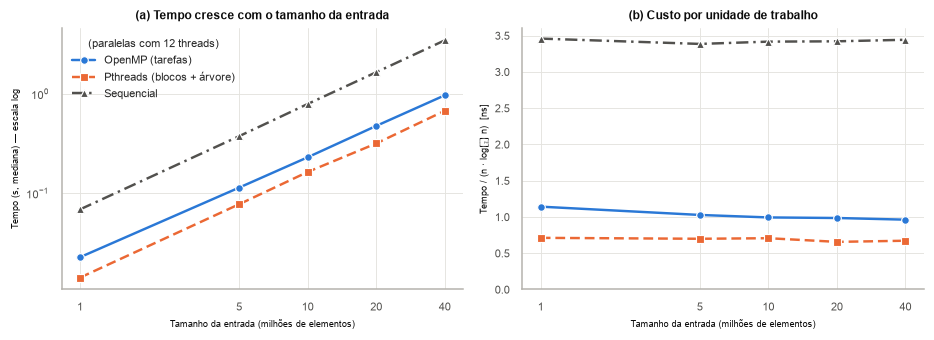

Expoente empírico b em t ∝ n^b. Para n log n entre 1M e 40M, o esperado é b ≈ 1.064.


versao,omp,pthreads,seq
threads,,,
1,1.0650,1.0590,1.0630
2,1.0570,1.0550,NaN
4,1.0540,1.0340,NaN
6,1.0430,1.0350,NaN
8,1.0400,1.0410,NaN
10,1.0230,1.0480,NaN
12,1.0180,1.0450,NaN


In [19]:
r = com_rotulos(resumo)
r["n_milhoes"] = r["tamanho"] / 1e6
r["ns_por_nlogn"] = r["tempo_mediana"] / (r["tamanho"] * np.log2(r["tamanho"])) * 1e9
graf = r[(r["versao"] == "seq") | (r["threads"] == max(THREADS))]

fig, eixos = plt.subplots(1, 2, figsize=(8.6, 3.2))
sns.lineplot(data=graf, x="n_milhoes", y="tempo_mediana", **POR_VERSAO, ax=eixos[0])
eixos[0].set_xscale("log"); eixos[0].set_yscale("log")
eixos[0].set_ylabel("Tempo (s, mediana) — escala log")
eixos[0].set_title("(a) Tempo cresce com o tamanho da entrada", color=TINTA)

sns.lineplot(data=graf, x="n_milhoes", y="ns_por_nlogn", **POR_VERSAO, legend=False, ax=eixos[1])
eixos[1].set_xscale("log"); eixos[1].set_ylim(bottom=0)
eixos[1].set_ylabel("Tempo / (n · log₂ n)  [ns]")
eixos[1].set_title("(b) Custo por unidade de trabalho", color=TINTA)
for ax in eixos:
    ax.set_xticks([1, 5, 10, 20, 40]); ax.set_xticklabels(["1", "5", "10", "20", "40"]); ax.minorticks_off()
    ax.set_xlabel("Tamanho da entrada (milhões de elementos)")
eixos[0].legend(title=f"(paralelas com {max(THREADS)} threads)", fontsize=7.5, title_fontsize=7.5)
fig.tight_layout()
salvar(fig, "4_tempo_vs_tamanho")
plt.show()

# Expoente empírico: inclinação de log(t) x log(n)
linhas = []
for (v, p), s in resumo.groupby(["versao", "threads"]):
    b, a = np.polyfit(np.log(s["tamanho"]), np.log(s["tempo_mediana"]), 1)
    linhas.append({"versao": v, "threads": p, "expoente_b (t ∝ n^b)": b})
expo = pd.DataFrame(linhas)
n0, n1 = min(TAMANHOS), max(TAMANHOS)
b_teorico = np.log((n1 * np.log2(n1)) / (n0 * np.log2(n0))) / np.log(n1 / n0)
print(f"Expoente empírico b em t ∝ n^b. Para n log n entre {fmt_n(n0)} e {fmt_n(n1)}, o esperado é b ≈ {b_teorico:.3f}.")
expo.pivot(index="threads", columns="versao", values="expoente_b (t ∝ n^b)").round(3)

### 4.2 Tempo × número de threads

✔ salvo em analise\graficos\4_tempo_vs_threads.png


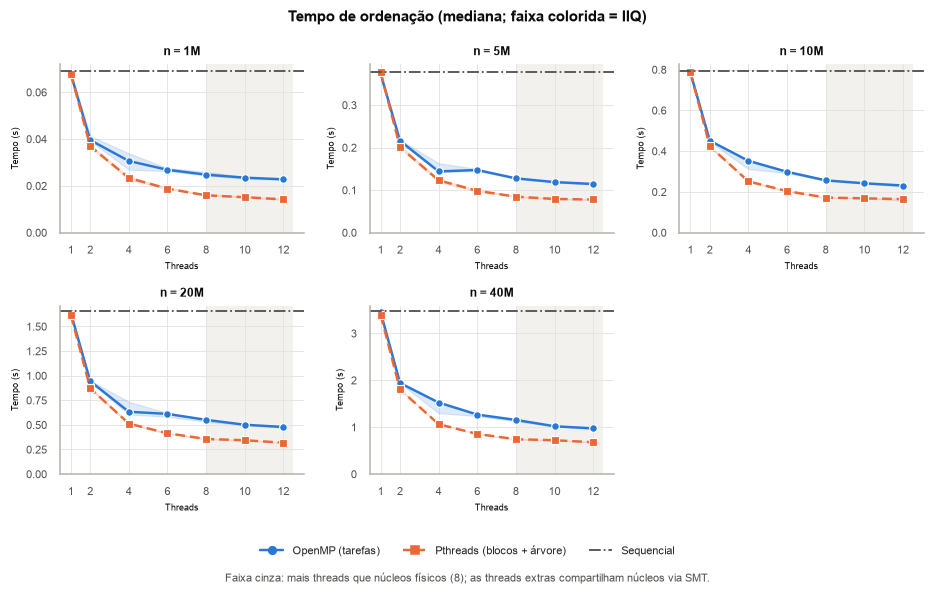

In [20]:
# Mediana das 10 repetições + faixa interquartil, calculadas pelo próprio seaborn
fig, eixos = grade_tamanhos()
for ax, n in zip(eixos, TAMANHOS):
    sub = dados[(dados["versao"] != "seq") & (dados["tamanho"] == n)]
    sns.lineplot(data=sub, x="threads", y="tempo", **POR_VERSAO, estimator="median",
                 errorbar=("pi", 50), err_kws={"alpha": 0.15}, legend=False, ax=ax)
    ax.axhline(t_seq[n], color=COR_SEQ, linestyle="-.", lw=1.2)
    eixo_threads(ax, THREADS)
    ax.set_ylim(bottom=0)
    ax.set_title(f"n = {fmt_n(n)}", color=TINTA)
    ax.set_xlabel("Threads"); ax.set_ylabel("Tempo (s)")
fig.suptitle("Tempo de ordenação (mediana; faixa colorida = IIQ)", color=TINTA, fontsize=10)
legenda_figura(fig, extras=["seq"])
fig.text(0.5, 0.0, NOTA_SMT, ha="center", fontsize=7.5, color=TINTA2)
salvar(fig, "4_tempo_vs_threads")
plt.show()

### 4.3 Memória × tamanho da entrada e número de threads

O Merge Sort usa dois vetores de *n* inteiros de 4 bytes (o vetor e o auxiliar), então o esperado é **≈ 8n bytes**, independentemente do número de threads. O pico medido inclui também o código, as bibliotecas e a pilha das threads.

In [21]:
# Memória: tabela no lugar do gráfico
mem_seq = resumo[resumo.versao == "seq"].set_index("tamanho")["mem_mib_mediana"]
par_m = resumo[resumo.versao != "seq"].copy()
par_m["dif"] = par_m["mem_mib_mediana"] - par_m["tamanho"].map(mem_seq)

linhas = []
for n in TAMANHOS:
    lin = {"n": fmt_n(n), "Teórico 8n (MiB)": round(8 * n / 2**20, 1), "Sequencial (MiB)": round(mem_seq[n], 1)}
    for v in VERSOES_PAR:
        s = par_m[(par_m.versao == v) & (par_m.tamanho == n)]
        lin[f"{NOME[v]} (MiB, 1–12 threads)"] = f"{s.mem_mib_mediana.min():.1f} – {s.mem_mib_mediana.max():.1f}"
    d = par_m[par_m.tamanho == n]["dif"]
    lin["Maior diferença p/ seq. (MiB)"] = round(d.abs().max(), 1)
    linhas.append(lin)
tab_mem = pd.DataFrame(linhas)
tab_mem.to_csv(TAB / "tabela_memoria.csv", index=False)
display(tab_mem.style.hide(axis="index"))

# Regressão linear: memória (bytes) = a + b * n
b, a = np.polyfit(dados["tamanho"], dados["mem_kb"] * 1024, 1)
r2 = np.corrcoef(dados["tamanho"], dados["mem_kb"])[0, 1] ** 2

n,Teórico 8n (MiB),Sequencial (MiB),"OpenMP (MiB, 1–12 threads)","Pthreads (MiB, 1–12 threads)",Maior diferença p/ seq. (MiB)
1M,7.600000,9.200000,9.1 – 9.8,8.8 – 9.4,0.500000
5M,38.100000,39.900000,39.8 – 40.4,38.9 – 39.9,1.000000
10M,76.300000,78.100000,77.8 – 78.5,77.4 – 78.0,0.800000
20M,152.600000,154.400000,154.2 – 154.8,153.2 – 154.4,1.100000
40M,305.200000,307.000000,306.6 – 307.2,306.0 – 306.9,1.000000


### 4.4 Energia × tamanho da entrada e número de threads

Energia estimada pelo **modelo A** (o mais pessimista para as versões paralelas), em joules, para cada tamanho de entrada.

✔ salvo em analise\graficos\4_energia_vs_threads.png


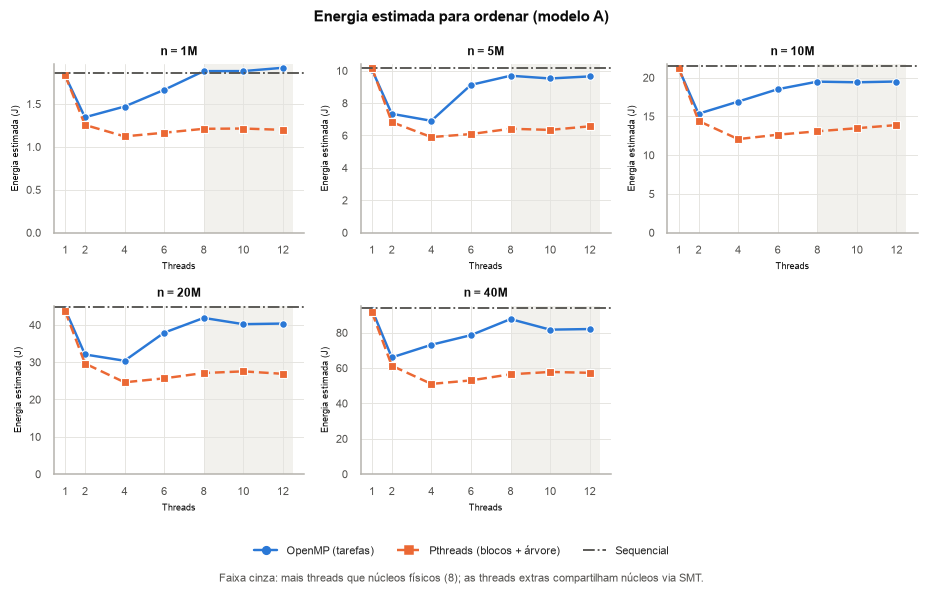

Energia estimada (J), modelo A:


versao      omp                                                 pthreads                                                     seq
threads      1       2       4       6       8       10      12       1       2       4       6       8       10      12      1 
1M       1.8300  1.3400  1.4700  1.6600  1.8800  1.8800  1.9200   1.8300  1.2500  1.1200  1.1600  1.2100  1.2100  1.2000  1.8600
5M      10.0600  7.3400  6.9000  9.1200  9.6900  9.5200  9.6400  10.1700  6.8200  5.9000  6.0800  6.4100  6.3400  6.5600 10.1700
10M     21.1400 15.3300 16.8900 18.4900 19.4700 19.3800 19.4800  21.2400 14.4000 12.0500 12.6200 13.0600 13.4600 13.8600 21.4500
20M     44.1000 32.0400 30.3600 37.8800 41.8400 40.1600 40.3300  43.6300 29.6200 24.5800 25.6400 27.0700 27.5100 26.8500 44.8000
40M     93.0500 65.9600 73.1100 78.5700 87.6600 81.6800 82.0200  91.5100 61.2800 50.9800 52.9600 56.4100 57.7400 57.2600 93.8700

In [22]:
fig, eixos = grade_tamanhos()
for ax, n in zip(eixos, TAMANHOS):
    sns.lineplot(data=enp[enp.tamanho == n], x="threads", y="E_A", **POR_VERSAO,
                 errorbar=None, legend=False, ax=ax)
    ax.axhline(en[(en.versao == "seq") & (en.tamanho == n)]["E_A"].iloc[0], color=COR_SEQ, linestyle="-.", lw=1.2)
    eixo_threads(ax, THREADS)
    ax.set_ylim(bottom=0)
    ax.set_title(f"n = {fmt_n(n)}", color=TINTA)
    ax.set_xlabel("Threads"); ax.set_ylabel("Energia estimada (J)")
fig.suptitle("Energia estimada para ordenar (modelo A)", color=TINTA, fontsize=10)
legenda_figura(fig, extras=["seq"])
fig.text(0.5, 0.0, NOTA_SMT, ha="center", fontsize=7.5, color=TINTA2)
salvar(fig, "4_energia_vs_threads")
plt.show()

t = en.pivot_table(index="tamanho", columns=["versao", "threads"], values="E_A")
t.index = [fmt_n(n) for n in t.index]
print("Energia estimada (J), modelo A:")
t.round(2)